# API document

[Zipline API](https://zipline.ml4trading.io/api-reference.html)

## Assets
### zipline.api.symbol(self, symbol_str, country_code=None)

Lookup an Equity by its ticker symbol.

#### Parameters:
- **symbol_str** (`str`): The ticker symbol for the equity to lookup.
- **country_code** (`str` or `None`, optional): A country to limit symbol searches to.

#### Returns:
- **equity**: The equity that held the ticker symbol on the current symbol lookup date.

#### Return type:
- `zipline.assets.Equity`

#### Raises:
- **SymbolNotFound**: Raised when the symbol was not held on the current lookup date.


## Data Object

### history()

Returns a trailing window of length `bar_count` with data for the given assets, fields, and frequency, adjusted for splits, dividends, and mergers as of the current simulation time.

The semantics for missing data are identical to the ones described in the notes for `current()`.

#### Parameters:
- **assets** (`zipline.assets.Asset` or iterable of `zipline.assets.Asset`): The asset(s) for which data is requested.
- **fields** (`str` or iterable of `str`): Requested data field(s). Valid field names are: “price”, “last_traded”, “open”, “high”, “low”, “close”, and “volume”.
- **bar_count** (`int`): Number of data observations requested.
- **frequency** (`str`): String indicating whether to load daily or minutely data observations. Pass ‘1m’ for minutely data, ‘1d’ for daily data.

#### Returns:
- **history**: See notes below.

#### Return type:
- `pd.Series` or `pd.DataFrame` or `pd.Panel`


### can_trade()

For the given asset or iterable of assets, returns `True` if all of the following are true:
- The asset is alive for the session of the current simulation time (if the current simulation time is not a market minute, the next session is used).
- The asset’s exchange is open at the current simulation time or at the simulation calendar’s next market minute.
- There is a known last price for the asset.

#### Parameters:
- **assets** (`zipline.assets.Asset` or iterable of `zipline.assets.Asset`): Asset(s) for which tradability should be determined.

#### Notes:
- The second condition warrants some further explanation:
  - If the asset’s exchange calendar is identical to the simulation calendar, then this condition always returns `True`.
  - If there are market minutes in the simulation calendar outside of this asset’s exchange’s trading hours (for example, if the simulation is running on the CMES calendar but the asset is MSFT, which trades on the NYSE), during those minutes, this condition will return `False` (for example, 3:15 am Eastern on a weekday, during which the CMES is open but the NYSE is closed).

#### Returns:
- **can_trade**: Bool or series of bools indicating whether the requested asset(s) can be traded in the current minute.

#### Return type:
- `bool` or `pd.Series[bool]`

:
bool or pd.Series[bool]

## Orders

### zipline.api.order_percent(self, asset, target, limit_price=None, stop_price=None, style=None)

Place an order in the specified asset corresponding to the given percent of the current portfolio value.

#### Parameters:
- **asset** (`Asset`): The asset that this order is for.
- **target** (`float`): The percentage of the portfolio value to allocate to asset. This is specified as a decimal, for example: 0.50 means 50%.
- **limit_price** (`float`, optional): The limit price for the order.
- **stop_price** (`float`, optional): The stop price for the order.
- **style** (`ExecutionStyle`, optional): The execution style for the order.

#### Returns:
- **order_id**: The unique identifier for this order.

#### Return type:
- `str`


## Scheduling Functions
### zipline.api.schedule_function(self, func, date_rule=None, time_rule=None, half_days=True, calendar=None)

Schedule a function to be called repeatedly in the future.

#### Parameters:
- **func** (`callable`): The function to execute when the rule is triggered. `func` should have the same signature as `handle_data`.
- **date_rule** (`zipline.utils.events.EventRule`, optional): Rule for the dates on which to execute `func`. If not passed, the function will run every trading day.
- **time_rule** (`zipline.utils.events.EventRule`, optional): Rule for the time at which to execute `func`. If not passed, the function will execute at the end of the first market minute of the day.
- **half_days** (`bool`, optional): Should this rule fire on half days? Default is `True`.
- **calendar** (`Sentinel`, optional): Calendar used to compute rules that depend on the trading calendar.


## zipline.run_algorithm(...)

Run a trading algorithm.

#### Parameters:
- **start** (`datetime`): The start date of the backtest.
- **end** (`datetime`): The end date of the backtest.
- **initialize** (`callable[context -> None]`): The initialize function to use for the algorithm. This is called once at the very beginning of the backtest and should be used to set up any state needed by the algorithm.
- **capital_base** (`float`): The starting capital for the backtest.
- **handle_data** (`callable[(context, BarData) -> None]`, optional): The handle_data function to use for the algorithm. This is called every minute when `data_frequency == 'minute'` or every day when `data_frequency == 'daily'`.
- **before_trading_start** (`callable[(context, BarData) -> None]`, optional): The before_trading_start function for the algorithm. This is called once before each trading day (after initialize on the first day).
- **analyze** (`callable[(context, pd.DataFrame) -> None]`, optional): The analyze function to use for the algorithm. This function is called once at the end of the backtest and is passed the context and the performance data.
- **data_frequency** (`{'daily', 'minute'}`, optional): The data frequency to run the algorithm at.
- **bundle** (`str`, optional): The name of the data bundle to use to load the data to run the backtest with. This defaults to ‘quantopian-quandl’.
- **bundle_timestamp** (`datetime`, optional): The datetime to lookup the bundle data for. This defaults to the current time.
- **trading_calendar** (`TradingCalendar`, optional): The trading calendar to use for your backtest.
- **metrics_set** (`iterable[Metric]` or `str`, optional): The set of metrics to compute in the simulation. If a string is passed, resolve the set with `zipline.finance.metrics.load()`.
- **benchmark_returns** (`pd.Series`, optional): Series of returns to use as the benchmark.
- **default_extension** (`bool`, optional): Should the default zipline extension be loaded. This is found at `$ZIPLINE_ROOT/extension.py`.
- **extensions** (`iterable[str]`, optional): The names of any other extensions to load. Each element may either be a dotted module path like `a.b.c` or a path to a python file ending in `.py` like `a/b/c.py`.
- **strict_extensions** (`bool`, optional): Should the run fail if any extensions fail to load. If this is false, a warning will be raised instead.
- **environ** (`mapping[str -> str]`, optional): The os environment to use. Many extensions use this to get parameters. This defaults to `os.environ`.
- **blotter** (`str` or `zipline.finance.blotter.Blotter`, optional): Blotter to use with this algorithm. If passed as a string, we look for a blotter construction function registered with `zipline.extensions.register` and call it with no parameters. Default is a `zipline.finance.blotter.SimulationBlotter` that never cancels orders.

#### Returns:
- **perf**: The daily performance of the algorithm.

#### Return type:
- `pd.DataFrame`


[pyfolio API](https://zipline.ml4trading.io/api-reference.html)

## Utilities

### pyfolio.utils.extract_rets_pos_txn_from_zipline(backtest)
`Extract returns, positions, transacti`ons, and leverage from the backtest data structure returned by `zipline.TradingAlgorithm.run()`.

The returned data structures are in a format compatible with the rest of pyfolio and can be directly passed to, for example, `tears.create_full_tear_sheet()`.

#### Parameters:
- **backtest** (`pd.DataFrame`): DataFrame returned by `zipline.TradingAlgorithm.run()`.

#### Returns:
- **returns** (`pd.Series`): Daily returns of the strategy. See full explanation in `tears.create_full_tear_sheet`.
- **positions** (`pd.DataFrame`): Daily net position values. See full explanation in `tears.create_full_tear_sheet`.
- **transactions** (`pd.DataFrame`): Prices and amounts of executed trades. One row per trade. See full explanation in `tears.create_full

## Tear Sheets

### pyfolio.tears.create_returns_tear_sheet

Generate a number of plots for analyzing a strategy’s return.

Fetches benchmarks, then creates the plots on a single figre.

Plots: rolling returns (with cone), rolling beta, rolling sharpe, rolling Fama-French risk factors, drawdowns, underwater plot, monthly and annual return plots, daily similarity plots, and return quantile boxplot.

Will also print the start and end dates of the strategy, performance statistics, drawdown periods, and the retur
n전략의 수익률을 분석하기 위한 여러 그림을 생성합니다.

벤치마크를 가져온 다음 단일 도형에 그림을 만듭니.

그림: 롤링 수익(콘 포함), 롤링 베타, 롤링 샤프, 롤링 파마-프렌치 위험 요인, 드로다운, 수중 그림, 월간 및 연간 수익 그림, 일일 유사도 및 수익 분위수 상자그림.

또한 전략의 시작일과 종료일, 성과 통계, 철회 기간 및 반환 범위를 인쇄합니다.


 range.

#### Parameters:
- **returns** (`pd.Series`): Daily returns of the strategy, noncumulative. See full explanation in `create_full_tear_sheet`.
- **positions** (`pd.DataFrame`, optional): Daily net position values. See full explanation in `create_full_tear_sheet`.
- **transactions** (`pd.DataFrame`, optional): Executed trade volumes and fill prices. See full explanation in `create_full_tear_sheet`.
- **live_start_date** (`datetime`, optional): The point in time when the strategy began live trading, after its backtest period.
- **cone_std** (`float` or `tuple`, optional): If float, the standard deviation to use for the cone plots. If tuple, a tuple of standard deviation values to use for the cone plots. The cone is a normal distribution with this standard deviation centered around a linear regression.
- **benchmark_rets** (`pd.Series`, optional): Daily noncumulative returns of the benchmark. This is in the same style as returns.
- **bootstrap** (`boolean`, optional): Whether to perform bootstrap analysis for the performance metrics. Takes a few minutes longer.
- **turnover_denom** (`str`, optional): Either 'AGB' or 'portfolio_value', default 'AGB'. See full explanation in `txn.get_turnover`.
- **header_rows** (`dict` or `OrderedDict`, optional): Extra rows to display at the top of the perf stats table.
- **return_fig** (`boolean`, optional): If True, returns the figure that was plotted on.
_tear_sheet`.


In [4]:
def initialize(context)-> None:
    context.universe = [symbol(s) for s in  sector_etfs]
    context.history_window = 20
    context.stocks_to_hold = 10
    schedule_function(func = handle_data,
                      date_rule = date_rules.month_start(), time_rule=time_rules.market_close(), half_days=True, calendar=None)

def month_perf(ts:"time series"):  # 수익률로 변환
    perf = (ts[-1] / ts[0] -1)
    return perf


def handle_data(context, data):
    hist = data.history(assets= context.universe, fields="close",bar_count = context.history_window, frequency = '1d')
    perf_table = hist.apply(month_perf).sort_values(ascending=False)
    buy_list = perf_table[: context.stocks_to_hold]
    the_rest = perf_table[context.stocks_to_hold:] 
    for stock, perf in buy_list.items():
        stock_weight = 1 / context.stocks_to_hold
        if data.can_trade(stock):
            order_target_percent(stock, stock_weight)
    for stock, perf in the_rest.items():
        if data.can_trade(stock):
            order_target_percent(stock, 0.0)     


def analyze(context, perf):
    returns, postions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf) #수익률, 포지션, 거래 반환
    pf.create_returns_tear_sheet(returns, benchmark_rets=None)

In [7]:
def initialize(context) -> None:
    context.universe = [symbol(s) for s in sector_etfs]
    context.history_window = 20  # 변동성 및 수익률 계산을 위한 기간
    context.stocks_to_hold = 10  # 보유할 최대 종목 수
    schedule_function(func=handle_data,
                      date_rule=date_rules.month_start(),
                      time_rule=time_rules.market_close(),
                      half_days=True, calendar=None)

# 월간 변동성 계산
def calculate_volatility(ts: "time series") -> float:
    return ts.pct_change().std()

# 리스크 패리티에 기반한 가중치 계산
def calculate_risk_parity_weights(perf_table, vol_table):
    # 변동성의 역수를 기준으로 가중치 계산
    inverse_vol = 1 / vol_table
    normalized_weights = inverse_vol / inverse_vol.sum()
    return normalized_weights

def handle_data(context, data):
    # 과거 데이터 로드 (종가 기준)
    hist = data.history(assets=context.universe, fields="close", bar_count=context.history_window, frequency='1d')

    # 월간 수익률 계산
    perf_table = hist.apply(lambda ts: ts[-1] / ts[0] - 1)

    # 월간 변동성 계산
    vol_table = hist.apply(calculate_volatility)

    # 상위 N개 종목 선택
    top_performers = perf_table.sort_values(ascending=False)[:context.stocks_to_hold]
    selected_vol_table = vol_table[top_performers.index]

    # 리스크 패리티 기반 가중치 계산
    weights = calculate_risk_parity_weights(top_performers, selected_vol_table)

    # 종목별 주문
    for stock, weight in weights.items():
        if data.can_trade(stock):
            order_target_percent(stock, weight)

    # 나머지 종목은 비중 0으로 설정
    for stock in context.universe:
        if stock not in weights.index and data.can_trade(stock):
            order_target_percent(stock, 0.0)

def analyze(context, perf):
    # Zipline의 퍼포먼스 데이터를 분석
    returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf)
    pf.create_returns_tear_sheet(returns, benchmark_rets=None)


In [8]:
start_date = pd.Timestamp('2022-01-01').tz_localize(None)
end_date = pd.Timestamp('2024-07-01').tz_localize(None)

Start date,2022-01-03
End date,2024-07-01
Total months,29
,Backtest
Annual return,6.477%
Cumulative returns,16.872%
Annual volatility,18.866%
Sharpe ratio,0.43
Calmar ratio,0.24
Stability,0.53
Max drawdown,-26.672%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,26.67,2022-01-03,2022-10-12,2023-12-18,511
1,5.50,2024-03-27,2024-04-19,2024-05-14,35
2,2.03,2023-12-28,2024-01-04,2024-01-19,17
3,1.76,2024-01-29,2024-01-31,2024-02-02,5
4,1.69,2024-05-21,2024-05-30,2024-06-05,12


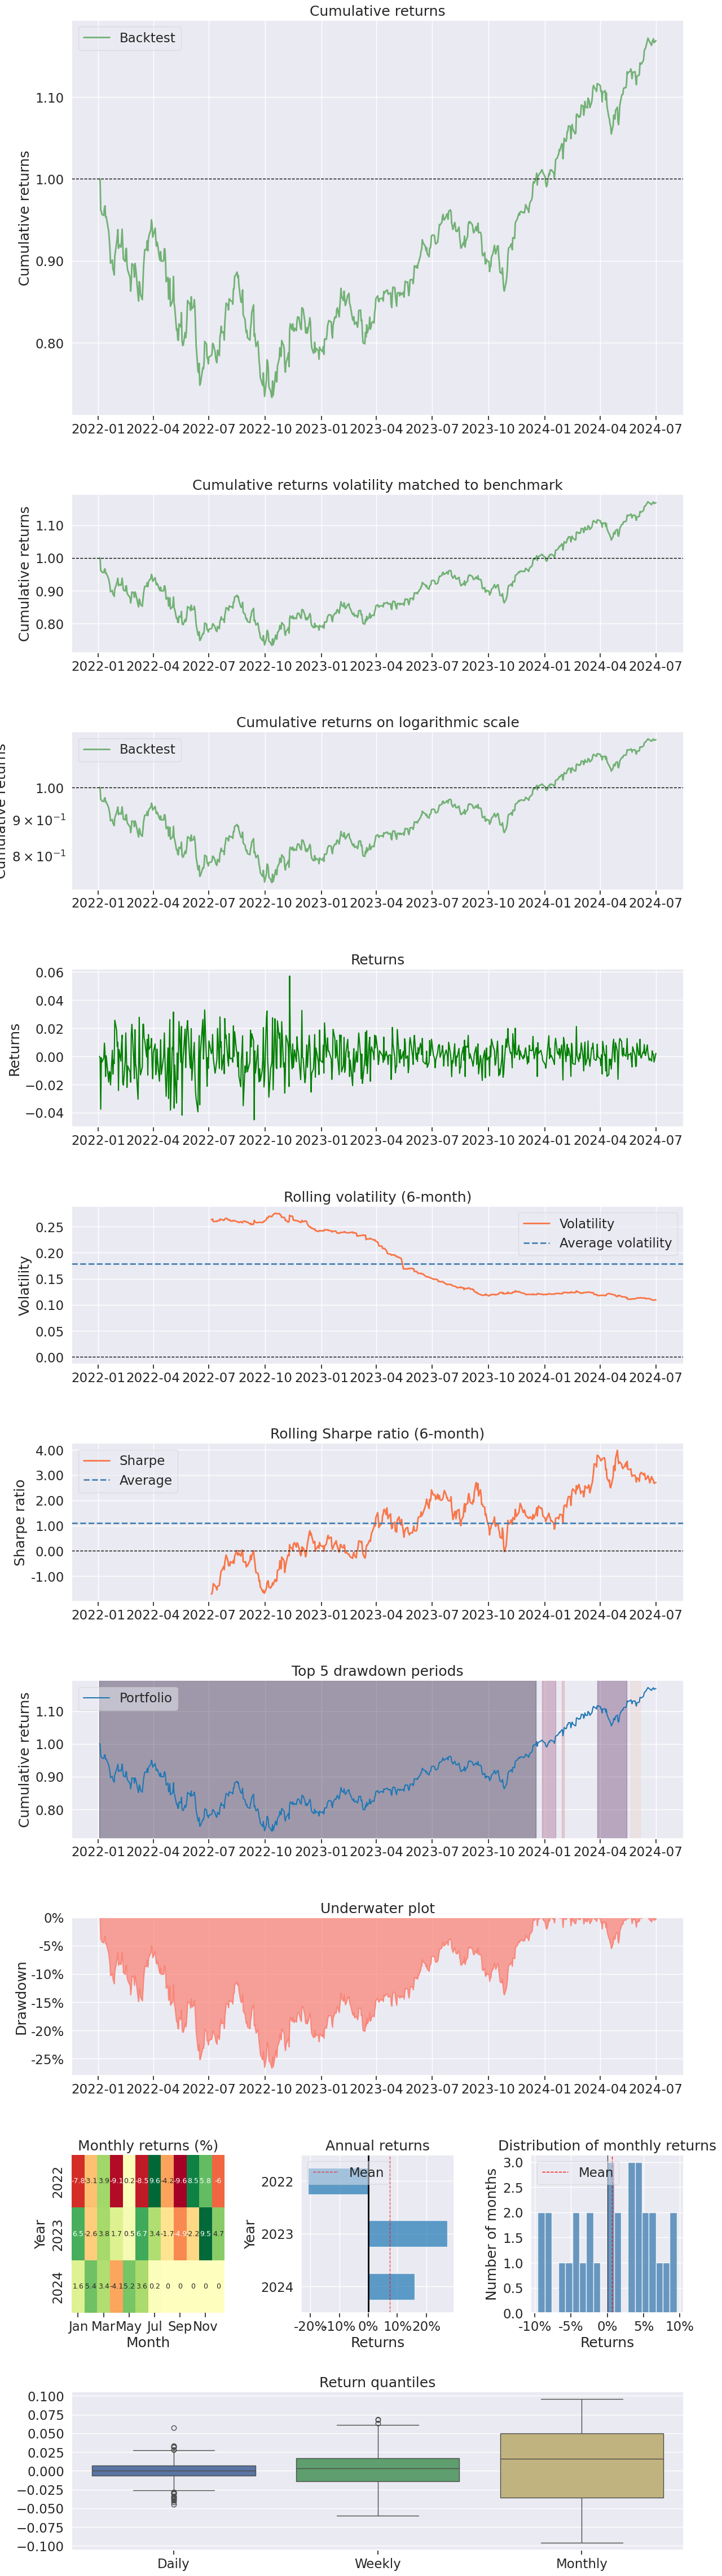

In [9]:
results = run_algorithm(
    start=start_date,
    end=end_date,
    initialize=initialize,
    handle_data=handle_data,
    analyze=analyze,
    capital_base=10000,
    data_frequency='daily',
    bundle='us_etfs'
)